In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from useful_functions_global import *
import glob
from pathlib import Path
import simple_adl.simple_adl.coordinate_tools as coordinate_tools
import simple_adl.simple_adl.isochrone as isochrone

my_path =  '/sdf/data/rubin/user/kexcel/'
my_plotspath = my_path + 'plots/'
euclid_blue = 'xkcd:cornflower blue'

In [25]:
class DataFrame():
    def __init__(self, survey, data, field):
        self.survey = survey
        self.data = data
        self.field = field
        
        ## coordinates
        self.ra_limits = (data['coord_ra'].min(), data['coord_ra'].max())
        self.dec_limits = (data['coord_dec'].min(), data['coord_dec'].max())
        self.rubin_ra = data['coord_ra']
        self.rubin_dec = data['coord_dec']
        self.euclid_ra = data['RIGHT_ASCENSION']
        self.euclid_dec = data['DECLINATION']

        ## Euclid bands (flux given in mu_Jy, convert to nJy)
        num = 2 #as suggested in Zerjal et al
        self.H_mag = flux2mag(data[f'FLUX_H_{num}FWHM_APER']*(10**3))
        self.Y_mag = flux2mag(data[f'FLUX_Y_{num}FWHM_APER']*(10**3))
        self.J_mag = flux2mag(data[f'FLUX_J_{num}FWHM_APER']*(10**3))
        self.VIS_mag = flux2mag(data[f'FLUX_VIS_2FWHM_APER']*(10**3))
        ## Rubin bands
        self.g_mag = flux2mag(data['g_psfFlux'])
        self.r_mag = flux2mag(data['r_psfFlux'])
        self.i_mag = flux2mag(data['i_psfFlux'])
        self.z_mag = flux2mag(data['z_psfFlux'])

        self.pointlikeprob = data['POINT_LIKE_PROB']
        self.ellipticity = data['ELLIPTICITY']
        self.mumax_minus_mag = self.data['MUMAX_MINUS_MAG']
        
    def tract(self, tract):
        self.tract = tract
        
    def Zerjal_cut(self):
        stars_mask = (self.ellipticity < 0.2) 
        stars_mask &= (self.mumax_minus_mag< -2.7) & (self.mumax_minus_mag> -3.25)
        return stars_mask, self.apply_mask(stars_mask)

    def POINT_LIKE_PROB_cut(self, threshold):
        stars_mask = (self.pointlikeprob > threshold)
        return stars_mask, self.apply_mask(stars_mask)

    def POINT_LIKE_FLAG_cut(self):
        stars_mask = (self.data['POINT_LIKE_FLAG'] == 1)
        return stars_mask, self.apply_mask(stars_mask)

    def apply_mask(self, mask):
        ## takes in a mask, applies it to the df, then returns another DataFrame object
        new_data = self.data[mask]
        return DataFrame(self.survey, new_data, self.field)

In [26]:
survey = 'dp2'

files = Path('.').glob(f'euclid_data/q1/*_{survey}_euclid_merged.parquet')
ecdfs_list = []
edfs_list = []
for file in files:
    with open(file, 'rb') as f:
        df = pd.read_parquet(f, engine='fastparquet')
    file = str(file)
    parquet = file[(file.rfind('/')+1):]
    tract = int(parquet[0:parquet.find('_')])
    field = get_field(tract)
    if field == 'EDFS':
        edfs_list.append((df, tract))
    elif field == 'ECDFS':
        ecdfs_list.append((df, tract))

In [27]:
DF = DataFrame('dp2', ecdfs_list[1][0], 'ECDFS')
DF.tract(ecdfs_list[1][1])

In [36]:
df = DF.data

#for column in df.columns:
#    if 'DECAM' in column:
#        print(column)
#columns = []
mags = {}
for band in 'ugriz':
    #columns.append(f'FLUX_{band}_EXT_DECAM_2FWHM_APER')
    mags[band] = flux2mag(df[f'FLUX_{band.upper()}_EXT_DECAM_2FWHM_APER']*(10**3))

(32.0, 18.0)

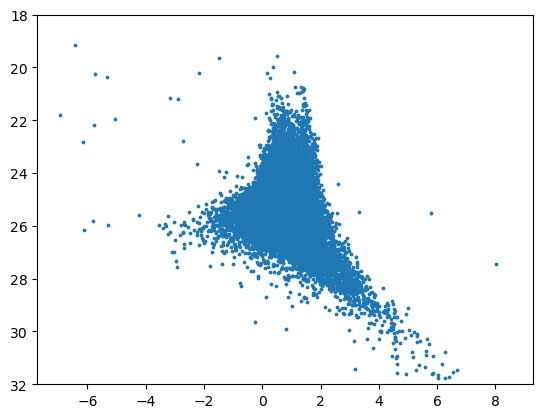

In [39]:
plt.scatter(mags['g']-mags['r'], mags['g'],s=3)
plt.ylim(32,18)